In [38]:
# ==============================
# 1. SETUP
# ==============================

!pip install transformers datasets wordcloud --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

from wordcloud import WordCloud

import re
import string

# reproducibility
np.random.seed(42)


In [39]:
# ==============================
# 2. LOAD DATA
# ==============================

from google.colab import files
import io

uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[file_name]), encoding='latin-1')

print("Columns in dataset:", df.columns)

# Try to auto-detect columns
if 'v1' in df.columns and 'v2' in df.columns:
    df = df[['v1', 'v2']]
    df.columns = ['label', 'text']

elif 'label' in df.columns and 'text' in df.columns:
    df = df[['label', 'text']]

else:
    # fallback: assume first column = label, second = text
    df = df.iloc[:, :2]
    df.columns = ['label', 'text']

# Standardize labels
df['label'] = df['label'].astype(str).str.lower()

# Map labels to binary
df['label'] = df['label'].map({
    'ham': 0,
    'spam': 1,
    '0': 0,
    '1': 1
})

# Drop missing values
df = df.dropna()

print("\nCleaned dataset preview:")
print(df.head())

print("\nClass distribution:")
print(df['label'].value_counts())

Saving spam.csv to spam (2).csv
Columns in dataset: Index(['Category', 'Message'], dtype='object')

Cleaned dataset preview:
   label                                               text
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...

Class distribution:
label
0    4825
1     747
Name: count, dtype: int64


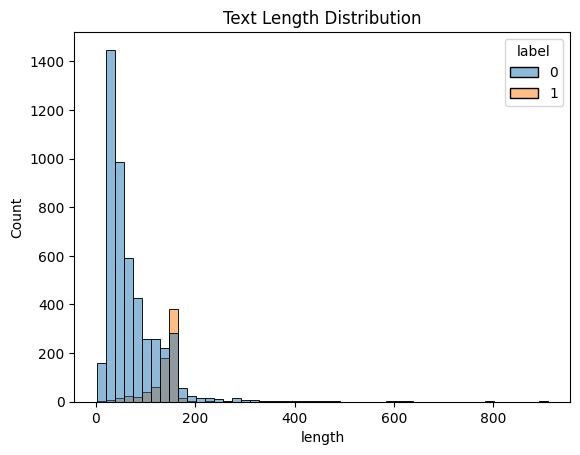

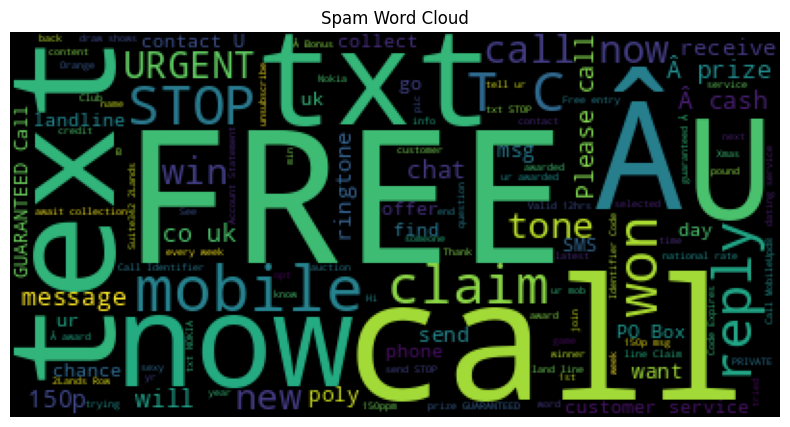

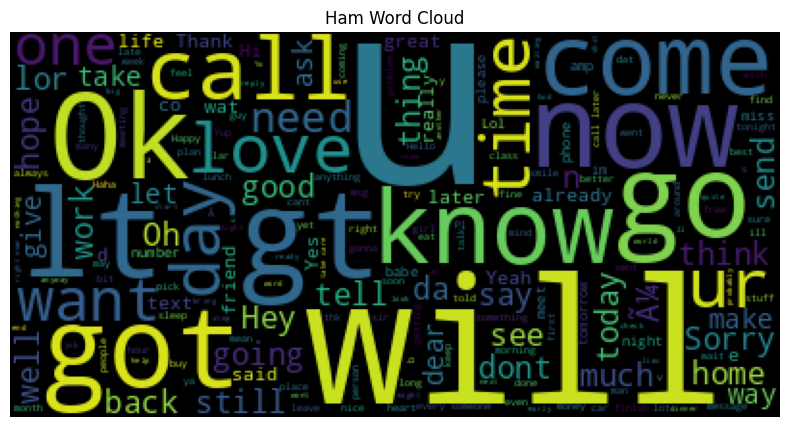

In [40]:
# ==============================
# 3. EDA + VISUALIZATION
# ==============================

# Text length
df['length'] = df['text'].apply(len)

plt.figure()
sns.histplot(data=df, x='length', hue='label', bins=50)
plt.title("Text Length Distribution")
plt.show()

# Word clouds
spam_words = ' '.join(df[df['label']==1]['text'])
ham_words = ' '.join(df[df['label']==0]['text'])

plt.figure(figsize=(10,5))
plt.imshow(WordCloud().generate(spam_words))
plt.title("Spam Word Cloud")
plt.axis('off')
plt.show()

plt.figure(figsize=(10,5))
plt.imshow(WordCloud().generate(ham_words))
plt.title("Ham Word Cloud")
plt.axis('off')
plt.show()

In [41]:
# ==============================
# 4. PREPROCESSING
# ==============================

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

df['clean_text'] = df['text'].apply(clean_text)

In [42]:
# ==============================
# 5. TRAIN TEST SPLIT
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['label'], test_size=0.2, random_state=42
)

In [43]:
# ==============================
# 6. BASELINE MODELS
# ==============================

# Naive Bayes
nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('model', MultinomialNB())
])

# Logistic Regression
lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('model', LogisticRegression(max_iter=200))
])

nb_pipeline.fit(X_train, y_train)
lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer(stop_words='english')),
                ('model', LogisticRegression(max_iter=200))])

In [44]:
# ==============================
# 7. EVALUATION FUNCTION
# ==============================

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    print(f"\n{name} RESULTS")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{name} Confusion Matrix")
    plt.show()

    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC_AUC': roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    }


Naive Bayes RESULTS
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       1.00      0.75      0.86       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



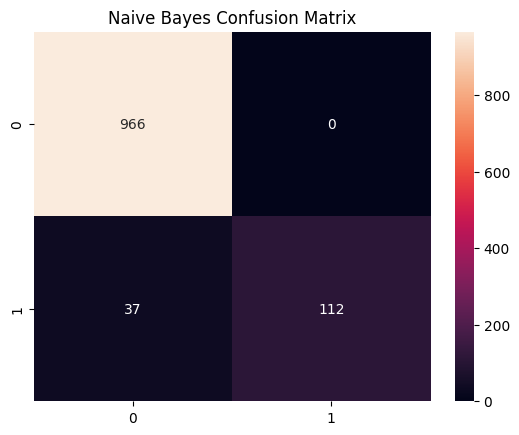


Logistic Regression RESULTS
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       1.00      0.72      0.84       149

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115



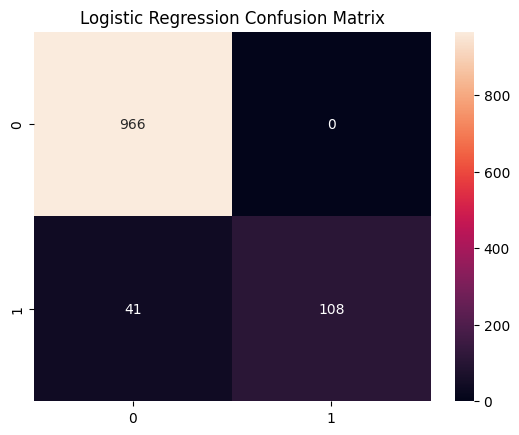

In [45]:
# ==============================
# 8. RUN EVALUATION
# ==============================

nb_results = evaluate_model("Naive Bayes", nb_pipeline, X_test, y_test)
lr_results = evaluate_model("Logistic Regression", lr_pipeline, X_test, y_test)

In [52]:
# ==============================
# 9. CROSS VALIDATION
# ==============================

cv_nb = cross_val_score(nb_pipeline, X_train, y_train, cv=5)
cv_lr = cross_val_score(lr_pipeline, X_train, y_train, cv=5)

print("NB CV Accuracy:", cv_nb.mean())
print("LR CV Accuracy:", cv_lr.mean())

NB CV Accuracy: 0.958042054828303
LR CV Accuracy: 0.9519839652126647


In [53]:
# ==============================
# 10. RULE-BASED LAYER (HYBRID)
# ==============================

spam_keywords = ['win', 'free', 'cash', 'prize', 'urgent', 'claim']

def rule_based_filter(text):
    for word in spam_keywords:
        if word in text:
            return 1
    return None

def hybrid_predict(text):
    rule = rule_based_filter(text)
    if rule is not None:
        return rule
    return lr_pipeline.predict([text])[0]

# Apply hybrid
y_pred_hybrid = [hybrid_predict(x) for x in X_test]

print("\nHYBRID MODEL")
print(classification_report(y_test, y_pred_hybrid))


HYBRID MODEL
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       966
           1       0.79      0.79      0.79       149

    accuracy                           0.94      1115
   macro avg       0.88      0.88      0.88      1115
weighted avg       0.94      0.94      0.94      1115



In [54]:
# ==============================
# 11. MODEL COMPARISON TABLE
# ==============================

results_df = pd.DataFrame([nb_results, lr_results])
results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Naive Bayes,0.966816,1.0,0.751678,0.858238,0.980547
1,Logistic Regression,0.963229,1.0,0.724832,0.840467,0.986633


In [55]:
# ==============================
# 12. TRANSFORMER MODEL
# ==============================

from transformers import pipeline

classifier = pipeline("text-classification", model="distilbert-base-uncased-finetuned-sst-2-english")

# Sample subset for speed
sample_texts = X_test[:200]

preds = []
for text in sample_texts:
    result = classifier(text[:512])[0]
    preds.append(1 if result['label']=='POSITIVE' else 0)

print("Transformer sample predictions done")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Transformer sample predictions done


In [57]:
# ==============================
# 13. FINAL OUTPUT (RANDOM EMAIL TEST)
# ==============================

import random

random_index = random.randint(0, len(df)-1)

sample_email = df.iloc[random_index]['text']
actual_label = "Spam" if df.iloc[random_index]['label'] == 1 else "Not Spam"

predicted_label = predict_email(sample_email)

print("EMAIL:")
print(sample_email)

print("\nACTUAL:", actual_label)
print("PREDICTED:", predicted_label)

EMAIL:
Whatsup there. Dont u want to sleep

ACTUAL: Not Spam
PREDICTED: Ham
